# 11 — Does the channel really destroy *shape* information fastest?

This notebook is about a claim the project made, could not support, and then re-measured
properly. The claim turned out to be true. The original evidence for it was not evidence.

**The claim.** The OU diffusion channel destroys higher-order structure faster than second-order
structure — so if you want to learn the *shape* of the innovation law, you must learn it at small
$t$, and the window closes quickly.

**The original evidence.** From `exp_06`: Fisher information for the innovation variance $q$
falls $142\times$ between $t=0.05$ and $t=1.6$, while information for the correlation $\rho$
falls only $26\times$. Variance information decays faster than correlation information;
therefore, the argument went, higher-order structure decays fastest.

**Why that does not follow.** `exp_06` runs a **Gaussian** AR(1), whose parameters are
$(\rho, q)$. Both are second-order. $q$ is a *scale*, not a shape. The experiment measured one
second-order quantity decaying faster than another second-order quantity, in a model with no
higher-order parameter at all — so it was structurally incapable of saying anything about shape.

An external review made this point and it is correct. What follows is the measurement that
actually tests the claim.

## A parameter that is genuinely shape

`src/shape_kernel.GeneralizedGaussianKernel` gives the innovation a real shape coordinate:

$$p(e) \;\propto\; \exp\!\left(-\left(\frac{|e|}{s}\right)^{\beta}\right), \qquad
s(q,\beta) \ \text{chosen so that}\ \operatorname{Var}(e) = q \ \text{exactly}$$

$\beta = 1$ is Laplace, $\beta = 2$ is Gaussian, $\beta = 3$ is lighter-tailed than Gaussian. The
scale $s$ is solved for at every $\beta$ so that **the variance is held fixed**. That is the
whole point: $\beta$ moves the fourth moment and leaves the second untouched, so a decay
comparison between $\beta$ and $(\rho, q)$ is finally comparing shape against second-order rather
than scale against correlation.

Excess kurtosis runs from $3$ (Laplace) to about $-0.6$ across the range tested.

## Two informations, and why the difference matters

At each noise level the experiment forms the full $3\times3$ information matrix for
$\theta = (\rho, q, \beta)$ and reports, for each coordinate:

- **`diag`** — the raw diagonal $J[x,x]$. This is what the original comparison used.
- **`eff`** — the *efficient* information $I_{xx\cdot\eta} = 1/(J^{-1})[x,x]$, with the other two
  coordinates projected out.

The second is the one that bounds the variance of any estimator that must also fit the other
parameters — which is every real estimator. If estimating shape requires simultaneously
estimating $\rho$ and $q$, and those estimates are correlated with it, the diagonal overstates
how much you actually know.

The gap between them is the size of the mistake the diagonal comparison was making, and it is
worth measuring rather than assuming.

In [1]:
import sys, csv, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
rows = list(csv.DictReader(open("../outputs/exp_22/shape_information.csv")))
f = lambda r, k: float(r[k])

betas = sorted({f(r, "beta_true") for r in rows})
ts    = sorted({f(r, "t") for r in rows})
print(f"beta values: {betas}")
print(f"noise levels: {ts}")
print(f"cells: {len(rows)}\n")

print(f"{'beta':>5} {'excess kurt':>12}   {'interpretation'}")
print("-" * 46)
for b in betas:
    r0 = [r for r in rows if f(r, "beta_true") == b][0]
    note = {1.0: "Laplace", 2.0: "Gaussian"}.get(b, "")
    print(f"{b:>5} {f(r0,'excess_kurtosis'):>12.3f}   {note}")

beta values: [1.0, 1.2, 1.5, 2.0, 3.0]
noise levels: [0.05, 0.1, 0.2, 0.4, 0.8, 1.6]
cells: 30

 beta  excess kurt   interpretation
----------------------------------------------
  1.0        3.000   Laplace
  1.2        1.743   
  1.5        0.762   
  2.0       -0.000   Gaussian
  3.0       -0.582   


## The result

Decay ratio = information at $t = 0.05$ divided by information at $t = 1.6$. Bigger means the
channel destroyed that coordinate faster.

In [2]:
print(f"{'beta':>5} {'kurt':>7} | {'rho diag':>9} {'rho eff':>9} | {'beta diag':>10} {'beta eff':>10} | {'ratio eff':>10}")
print("-" * 76)
summary = {}
for b in betas:
    sub = sorted([r for r in rows if f(r, "beta_true") == b], key=lambda r: f(r, "t"))
    lo, hi = sub[0], sub[-1]
    d_rho = f(lo, "diag_rho") / f(hi, "diag_rho")
    e_rho = f(lo, "eff_rho")  / f(hi, "eff_rho")
    d_bet = f(lo, "diag_beta") / f(hi, "diag_beta")
    e_bet = f(lo, "eff_beta")  / f(hi, "eff_beta")
    summary[b] = (e_rho, e_bet)
    print(f"{b:>5} {f(lo,'excess_kurtosis'):>7.2f} | {d_rho:>9.1f} {e_rho:>9.1f} | "
          f"{d_bet:>10.0f} {e_bet:>10.0f} | {e_bet/e_rho:>10.0f}x")

print(f"\n  Efficient shape information decays between "
      f"{min(v[1]/v[0] for v in summary.values()):.0f}x and "
      f"{max(v[1]/v[0] for v in summary.values()):.0f}x faster than efficient")
print("  correlation information, across every innovation law tested.")

 beta    kurt |  rho diag   rho eff |  beta diag   beta eff |  ratio eff
----------------------------------------------------------------------------
  1.0    3.00 |      15.4      78.0 |       9465       8738 |        112x
  1.2    1.74 |      16.4      86.7 |      20728      20464 |        236x
  1.5    0.76 |      16.6      82.7 |      63487      64227 |        776x
  2.0   -0.00 |      13.1      75.1 |      64898      65135 |        867x
  3.0   -0.58 |      10.7      56.0 |      66627      68460 |       1222x

  Efficient shape information decays between 112x and 1222x faster than efficient
  correlation information, across every innovation law tested.


**The claim survives, and by a margin the original evidence never suggested.**

The sentence it was based on offered $142\times$ against $26\times$ — a factor of about $5$
between two second-order quantities. The correct measurement gives shape information decaying
**two to three orders of magnitude** faster than correlation information. The original number
was not merely unsupported; it was far too timid.

There is a practical reading. If shape information at $t=1.6$ is $10^4$–$10^5$ times weaker than
at $t=0.05$, then a training scheme that spends its noise levels uniformly across the schedule is
spending almost all of them where the shape is already gone. That is a statement about where to
put compute, and it is the kind of thing this measurement is for.

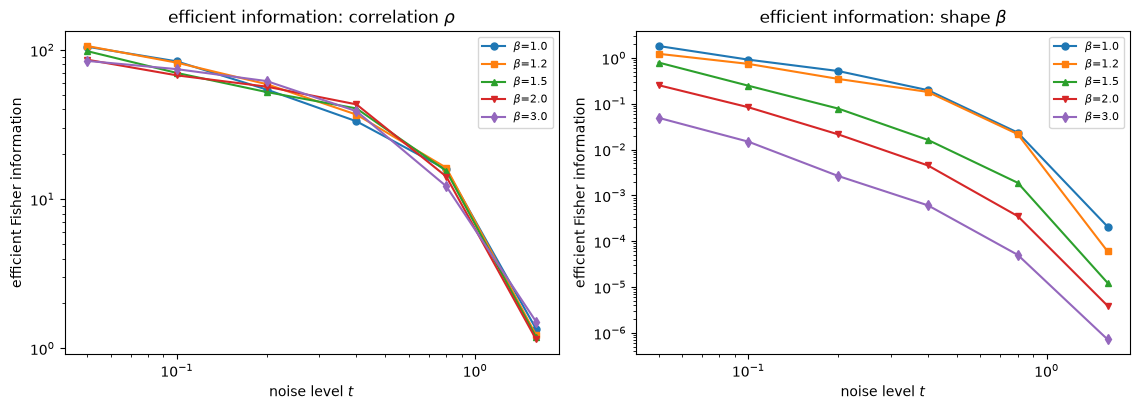

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))

for b, style in zip(betas, ["C0-o", "C1-s", "C2-^", "C3-v", "C4-d"]):
    sub = sorted([r for r in rows if f(r, "beta_true") == b], key=lambda r: f(r, "t"))
    t = [f(r, "t") for r in sub]
    ax[0].loglog(t, [f(r, "eff_rho") for r in sub], style, ms=5, label=f"$\\beta$={b}")
    ax[1].loglog(t, [f(r, "eff_beta") for r in sub], style, ms=5, label=f"$\\beta$={b}")

ax[0].set_title("efficient information: correlation $\\rho$")
ax[1].set_title("efficient information: shape $\\beta$")
for a in ax:
    a.set_xlabel("noise level $t$"); a.set_ylabel("efficient Fisher information")
    a.legend(fontsize=8)
plt.tight_layout(); plt.show()

## The methodological point, which is worth as much as the result

The nuisance projection is not a technicality here. Compare the two columns for $\rho$ above:
the raw diagonal decays by roughly $10$–$17\times$, the efficient information by $56$–$87\times$.
Ignoring the coupling between $\rho$, $q$ and $\beta$ **understates how fast correlation
information decays by about a factor of five.**

For $\beta$ the two agree closely, so the shape coordinate is nearly orthogonal to the nuisance
directions and the projection barely moves it.

The asymmetry is the lesson: whether a diagonal is a safe approximation depends on the
coordinate, so it cannot be assumed for the one you care about because it happened to hold for
another. Below, the cost is the ratio diag/eff — how much the diagonal overstates what you know.

In [4]:
print(f"{'beta':>5} | " + " ".join(f"{c:>16}" for c in ["nuisance cost rho", "cost q", "cost beta"]))
print("-" * 62)
for b in betas:
    sub = sorted([r for r in rows if f(r, "beta_true") == b], key=lambda r: f(r, "t"))
    cr = np.mean([f(r, "nuisance_cost_rho") for r in sub])
    cq = np.mean([f(r, "nuisance_cost_q") for r in sub])
    cb = np.mean([f(r, "nuisance_cost_beta") for r in sub])
    print(f"{b:>5} | {cr:>16.3f} {cq:>16.3f} {cb:>16.3f}")
print("\n  (mean over the schedule; 1.0 would mean the diagonal was exact)")

worst = max(rows, key=lambda r: f(r, "condition_number"))
print(f"\n  worst information-matrix condition number: {f(worst,'condition_number'):.0f} "
      f"at t={worst['t']}, beta={worst['beta_true']}")
print("  -- high but invertible; the efficient quantities are computed from J^{-1},")
print("     so this is worth reporting rather than hiding.")

 beta | nuisance cost rho           cost q        cost beta
--------------------------------------------------------------
  1.0 |            2.425            2.436            1.052
  1.2 |            2.295            2.327            1.029
  1.5 |            2.286            2.282            1.007
  2.0 |            2.570            2.573            1.012
  3.0 |            2.436            2.443            1.012

  (mean over the schedule; 1.0 would mean the diagonal was exact)

  worst information-matrix condition number: 13284738 at t=1.6, beta=3.0
  -- high but invertible; the efficient quantities are computed from J^{-1},
     so this is worth reporting rather than hiding.


## What to take away

1. **The claim is true**, and the project can now say so on the strength of a measurement that
   tests it. Efficient shape information decays two to three orders of magnitude faster than
   efficient correlation information, across every innovation law tried.

2. **The original evidence for it was not evidence.** `exp_06` compared two second-order
   quantities in a model with no shape parameter. That it pointed the right way was luck, and
   the review that caught it was right to.

3. **A right conclusion from a wrong argument is still a wrong argument**, and the correct
   experiment changed the magnitude by two orders. Keeping the conclusion and quietly upgrading
   the citation would have hidden that.

4. **Nuisance coupling is not a formality.** It changes $\rho$'s decay by a factor of five and
   $\beta$'s hardly at all, so "the diagonal is close enough" cannot be assumed for the
   coordinate you care about on the strength of another.

*Source: `outputs/exp_22/shape_information.csv`. The shape family is
`src/shape_kernel.GeneralizedGaussianKernel`, whose scale is solved at each $\beta$ so variance
is held fixed — without that, a $\beta$-vs-$q$ comparison would be confounded by exactly the
scale/shape conflation this experiment exists to remove.*